# Imports

In [1]:
import os
from pathlib import Path

In [2]:
import pandas as pd

In [3]:
from backtester import BackTester

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
data_store="../Prepared_Data_Store"

# BackTesting

## Trading Strategy-I:

### Here we will long the top returns and short the bottom returns values at a particular day as predicted by our Model-4

In [8]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [9]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model4_Factors",
    trading_strategy=trading_strategy
)

In [10]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-I...
[INFO]: Backtesting completed...


### Performance analysis using Pyfolio

#### Loading Benchmark Data

In [11]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [12]:
benchmark_data=benchmark_data.sp500_returns.tz_localize("UTC")

#### Extracting information from Zipline Results

In [13]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

In [14]:
LIVE_DATE="2016-02-24"

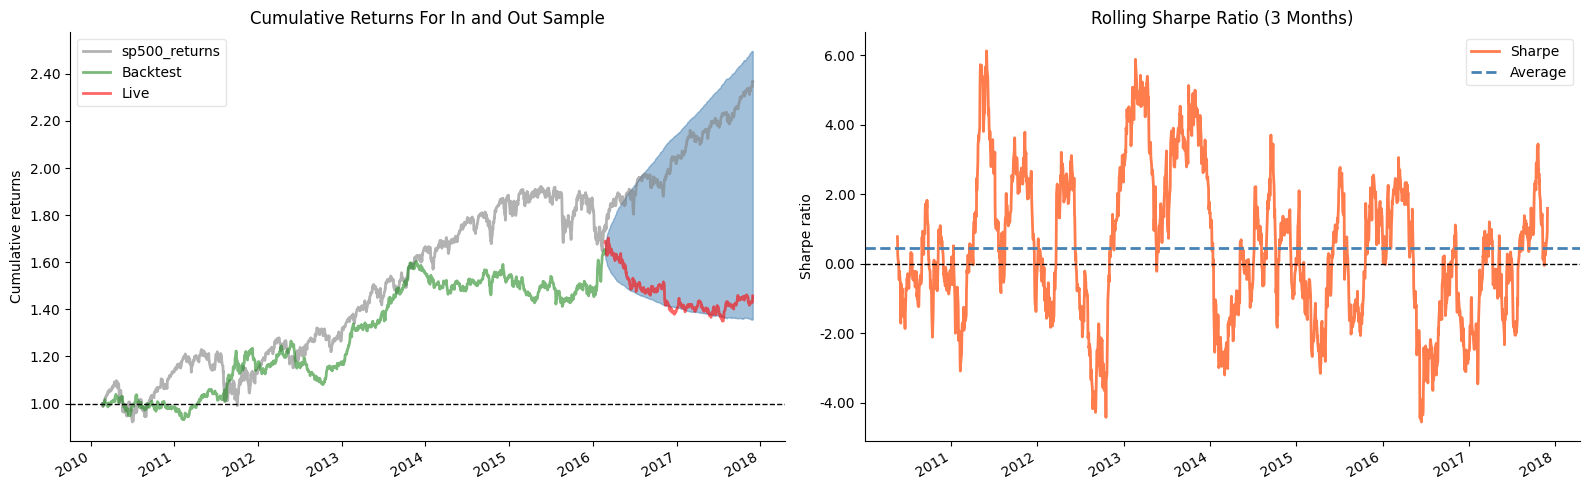

In [15]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,20.68,2016-03-09,2017-07-21,NaT,NaN
1,14.55,2012-05-24,2012-10-11,2013-02-05,184
2,11.91,2013-11-21,2015-08-21,2016-01-25,568
3,10.38,2010-04-21,2011-02-11,2011-05-11,276
4,8.83,2011-12-07,2012-02-01,2012-04-09,89


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.37%,-3.00%,3.72%
Fukushima,0.10%,-0.61%,1.17%
EZB IR Event,-0.10%,-1.25%,1.14%
Flash Crash,0.19%,-0.10%,0.55%
Apr14,-0.03%,-1.44%,0.70%
Oct14,-0.01%,-1.90%,2.35%
Fall2015,0.02%,-1.68%,1.15%
Recovery,0.02%,-3.08%,3.72%
New Normal,0.02%,-3.67%,4.57%


Top 10 long positions of all time,max
sid,
NFLX,43.05%
WTW,31.77%
URI,22.69%
AZO,20.69%
VRTX,20.57%
MDT,20.50%
DPZ,20.27%
FICO,20.06%
APD,19.88%


Top 10 short positions of all time,max
sid,
NFLX,-37.46%
URI,-28.17%
WTW,-26.52%
MNST,-24.99%
APD,-24.10%
WMB,-22.48%
ROST,-20.64%
INCY,-20.55%
SYK,-20.34%


Top 10 positions of all time,max
sid,
NFLX,43.05%
WTW,31.77%
URI,28.17%
MNST,24.99%
APD,24.10%
WMB,22.48%
AZO,20.69%
ROST,20.64%
VRTX,20.57%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$693117.38,$-1068402.63,$1761520.01
Gross profit,$26852850.58,$12427667.07,$14425183.51
Gross loss,$-26159733.21,$-13496069.70,$-12663663.50
Profit factor,$1.03,$0.92,$1.14
Avg. trade net profit,$9.07,$-28.87,$44.73
Avg. winning trade,$701.61,$697.79,$704.94
Avg. losing trade,$-696.98,$-713.66,$-680.04
Ratio Avg. Win:Avg. Loss,$1.01,$0.98,$1.04
Largest winning trade,$79172.64,$79172.64,$26370.96
Largest losing trade,$-35012.70,$-21621.08,$-35012.70


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 12:47:34.881280272,1 days 12:11:24.569718424,1 days 13:21:34.149756246
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,164 days 01:00:00,164 days 01:00:00,99 days 23:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.05%,0.05%,0.05%
Avg returns losing,-0.05%,-0.05%,-0.05%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.03%
Median returns losing,-0.03%,-0.03%,-0.03%
Largest winning trade,5.21%,5.21%,2.01%
Largest losing trade,-2.35%,-1.66%,-2.35%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,-0.00%,-0.01%,0.01%,0.00%,0.01%,-0.00%,0.00%,-0.00%,0.01%,-0.02%,-0.02%,0.00%,0.01%,-0.01%,-0.00%,-0.01%,-0.01%,0.00%,0.01%,-0.01%,0.01%,0.01%,-0.00%,-0.00%,-0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.00%,0.00%,0.00%,-0.01%,0.01%,0.00%,0.01%,0.00%,0.01%,0.01%,0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.01%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.01%,-0.01%,0.01%,-0.00%,-0.00%,0.01%,0.00%,-0.01%,0.01%,0.01%,-0.00%,0.01%,-0.01%,-0.00%,0.01%,0.01%,0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.01%,-0.00%,-0.02%,-0.01%,-0.00%,0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.02%,-0.00%,0.01%,0.00%,0.01%,0.00%,0.00%,0.00%,-0.01%,-0.01%,-0.01%,-0.01%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,0.01%,-0.01%,-0.00%,0.00%,-0.00%,0.02%,0.01%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.01%,0.01%,0.01%,0.01%,0.00%,0.00%,0.00%,0.03%,0.00%,-0.00%,0.01%,0.01%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,0.00%,0.01%,0.01%,-0.00%,-0.01%,0.00%,0.00%,-0.01%,-0.00%,-0.02%,-0.01%,0.01%,0.00%,0.00%,-0.03%,-0.00%,0.01%,0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,0.01%,-0.01%,0.00%,0.01%,-0.01%,0.00%,0.01%,0.00%,0.02%,-0.00%,-0.01%,0.02%,0.00%,-0.00%,0.00%,-0.00%,0.01%,-0.01%,-0.00%,0.02%,0.01%,0.00%,-0.00%,-0.01%,0.01%,0.01%,0.00%,-0.01%,-0.00%,0.01%,0.01%,0.01%,0.00%,0.01%,-0.00%,0.01%,-0.00%,-0.01%,0.01%,0.00%,-0.00%,0.00%,0.01%,0.00%,0.01%,0.00%,-0.01%,0.00%,-0.01%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,-0.01%,-0.01%,0.01%,0.00%,0.01%,0.00%,-0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.02%,0.00%,0.01%,-0.02%,-0.01%,0.01%,0.01%,0.00%,0.00%,-0.00%,-0.02%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,0.01%,0.00%,-0.00%,0.00%,0.01%,-0.00%,0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,0.02%,0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,-0.01%,0.00%,0.01%,-0.00%,-0.01%,-0.01%,0.01%,0.02%,-0.01%,-0.01%,0.00%,0.01%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,0.06%,0.00%,0.00%,0.01%,-0.00%,-0.01%,0.02%,-0.00%,-0.01%,0.01%,0.00%,0.01%,-0.00%
Avg returns winning,0

Profitability (PnL / PnL total) per name,
symbol,
WMB,24.11%
DECK,7.73%
BBY,6.88%
GIS,6.79%
MNST,6.46%
CRM,6.30%
MGM,6.14%
TAP,5.88%
BG,5.59%


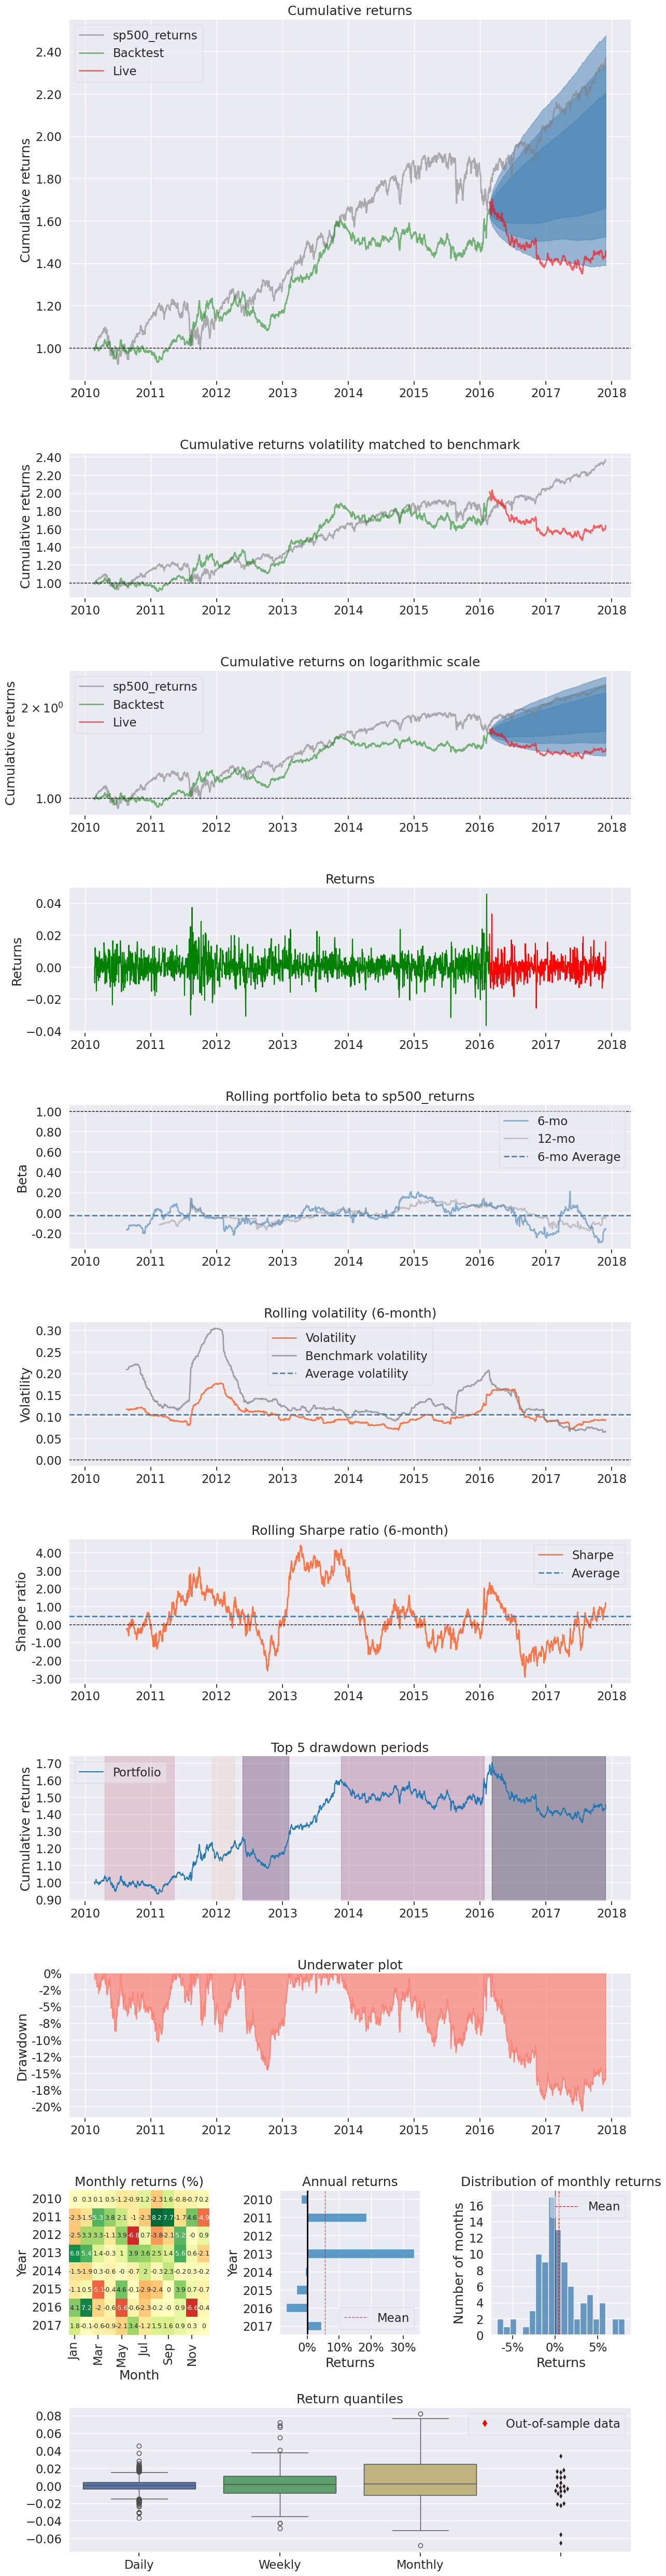

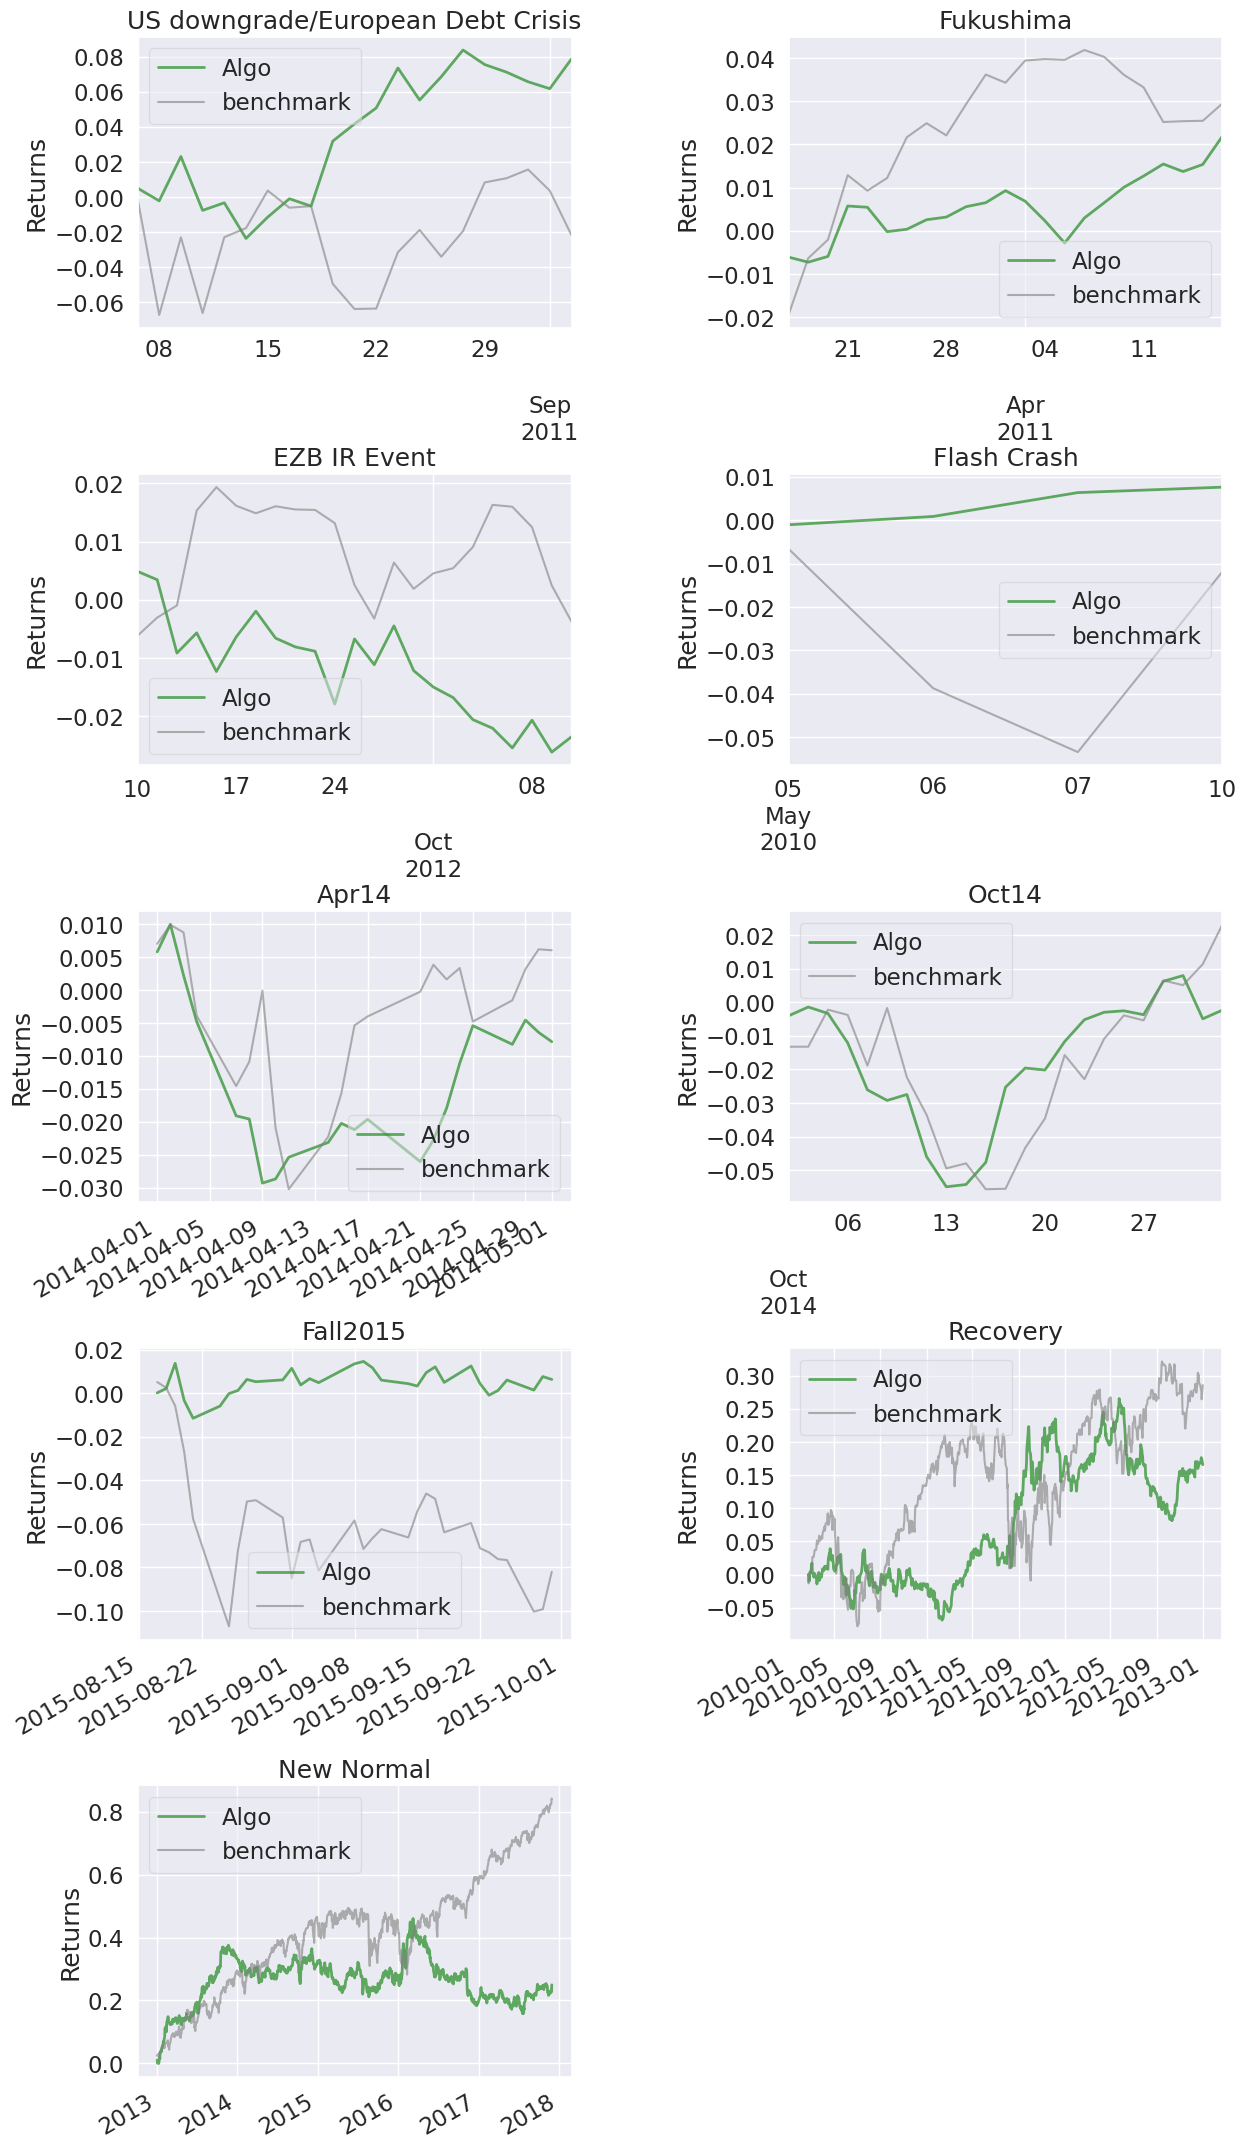

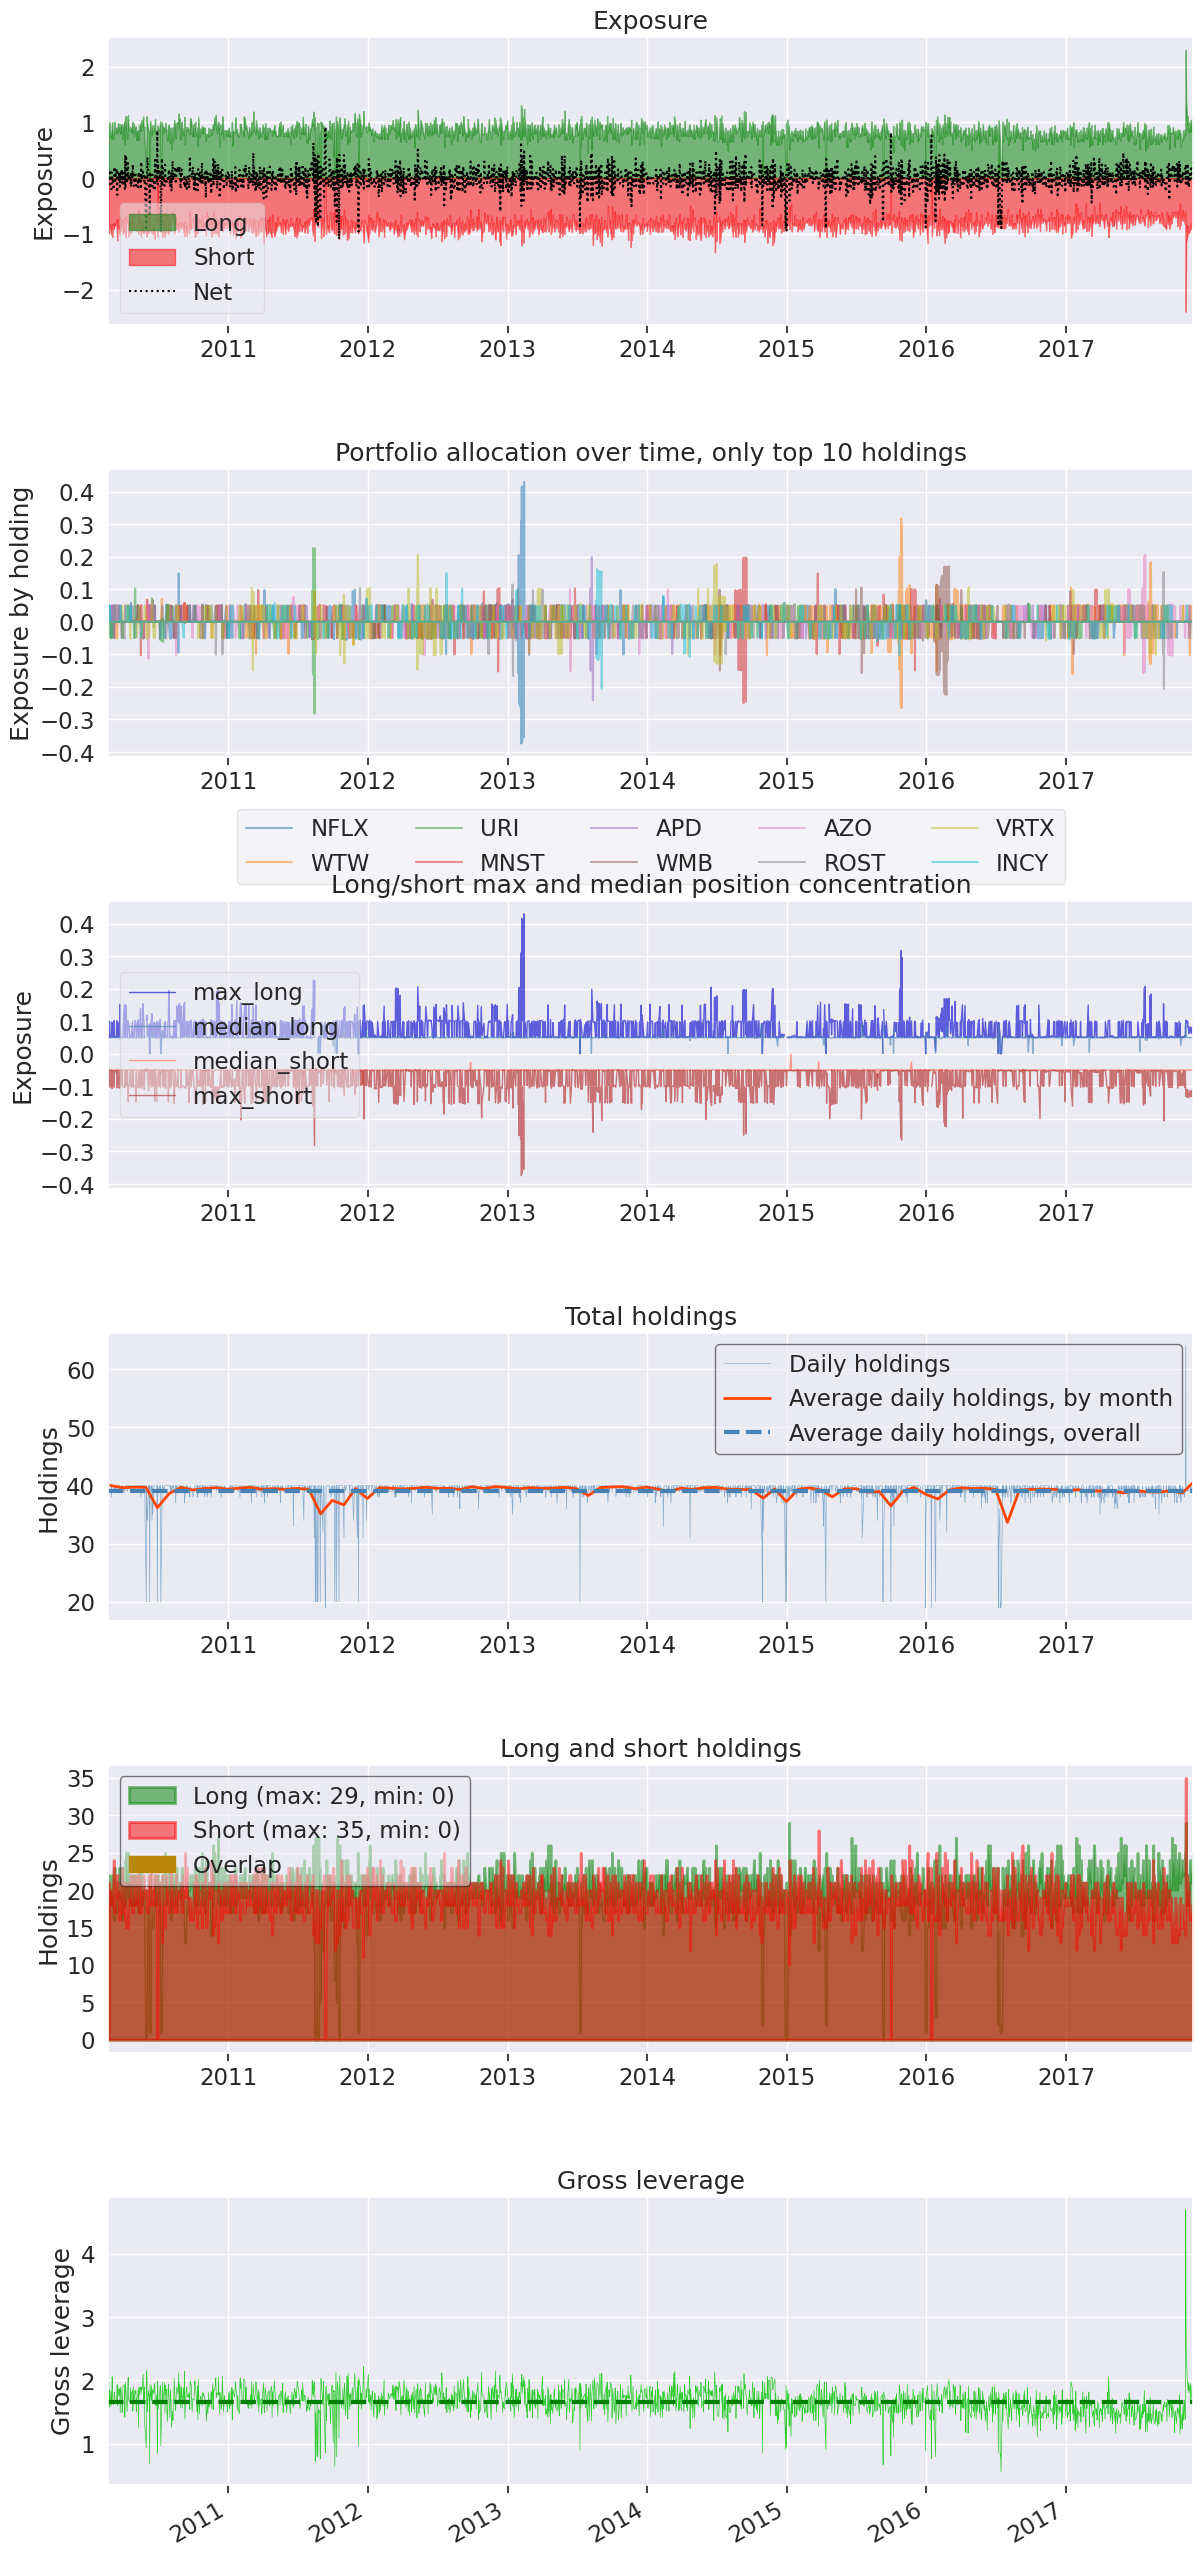

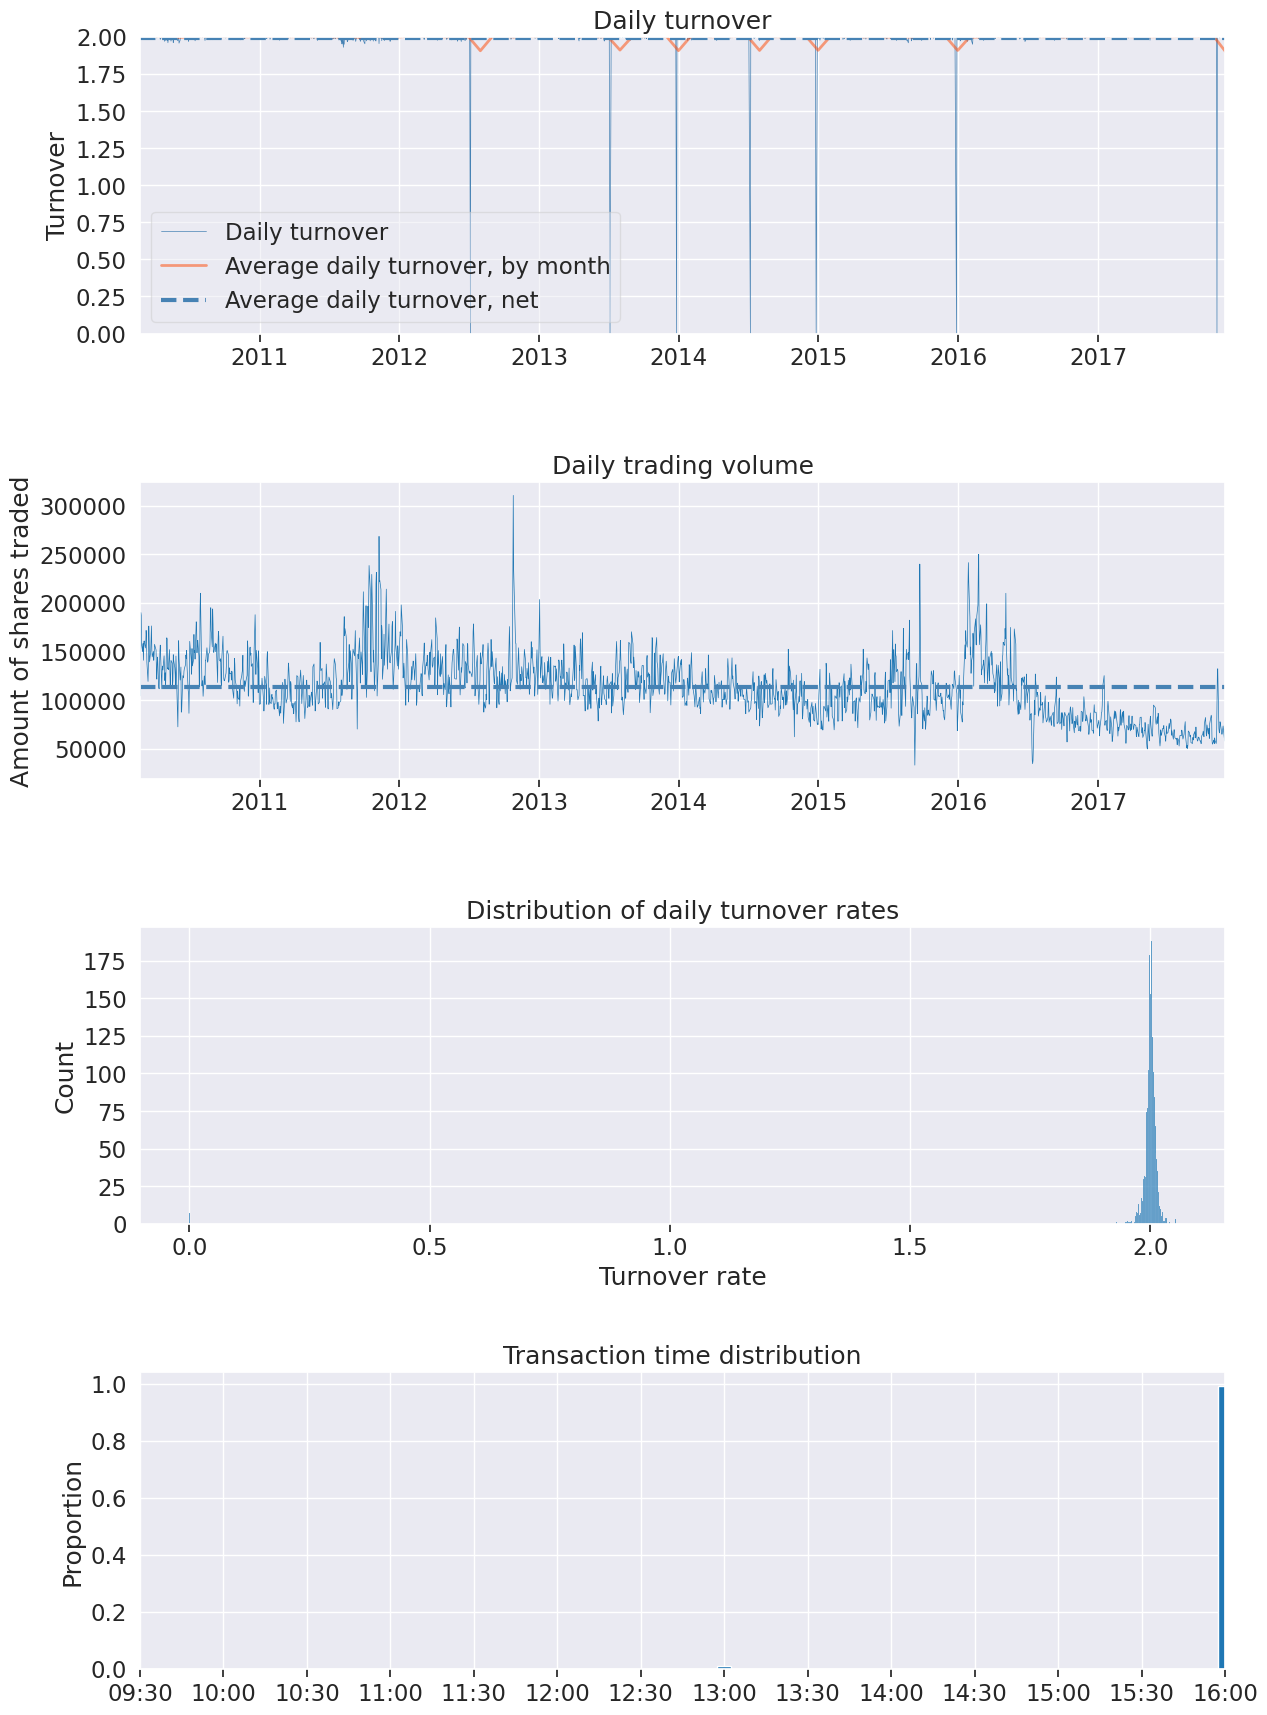

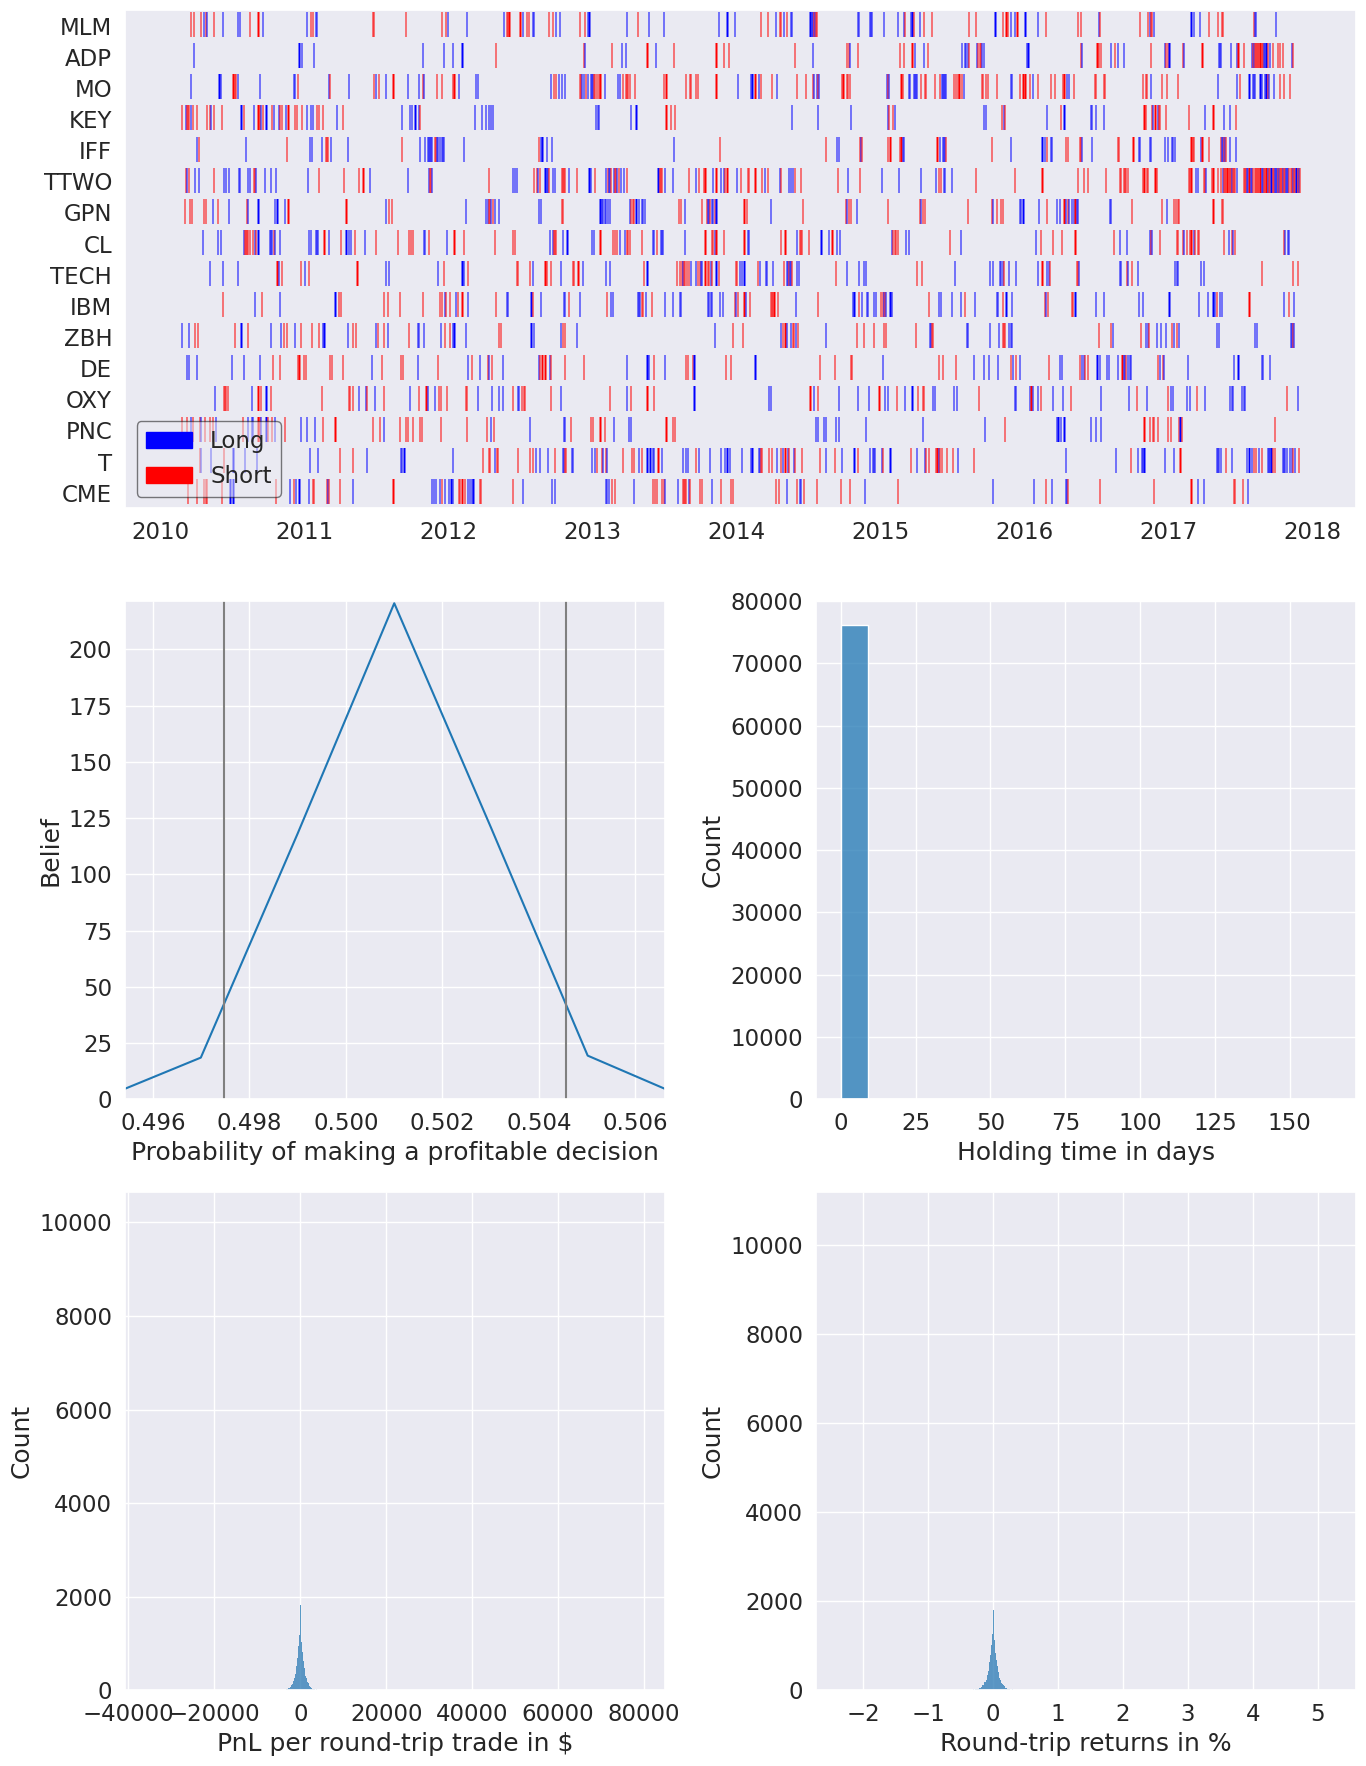

In [16]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)

## Trading Strategy-II:

### As per the Signal Evaluation of the Model-4 Factors, we will long and short predictions in quantiles 5 and 4 respectively.

In [17]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":5,
        "quantile_short":4
}

}

In [18]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model4_Factors",
    trading_strategy=trading_strategy
)

In [19]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-II...
[INFO]: Backtesting completed...


### Performance analysis using Pyfolio

#### Extracting information from Zipline Results

In [20]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

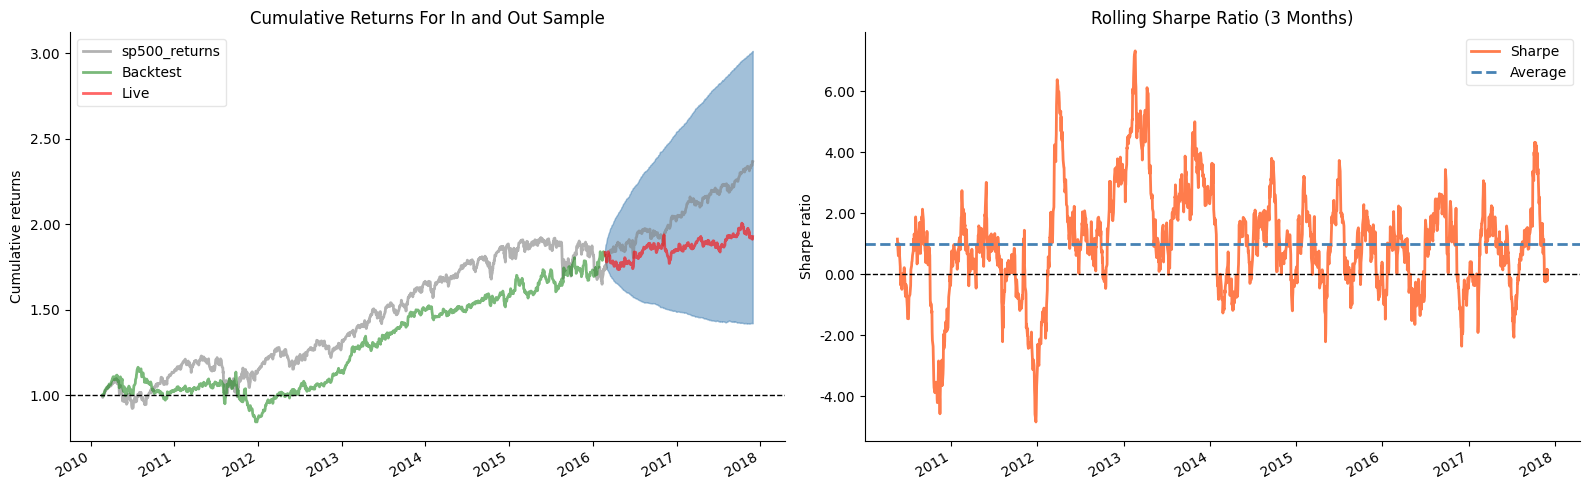

In [21]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,27.52,2010-07-27,2011-12-28,2013-01-17,648
1,10.81,2010-04-26,2010-06-02,2010-07-20,62
2,8.64,2016-11-07,2016-11-30,2017-09-05,217
3,7.83,2015-02-03,2015-03-25,2015-05-27,82
4,7.48,2015-07-02,2015-07-24,2015-08-27,41


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.34%,-6.19%,5.41%
Fukushima,0.07%,-1.57%,1.40%
EZB IR Event,0.02%,-0.61%,1.38%
Flash Crash,0.59%,-2.64%,4.39%
Apr14,0.02%,-1.55%,1.17%
Oct14,-0.06%,-1.56%,2.20%
Fall2015,0.07%,-2.31%,2.82%
Recovery,0.02%,-6.19%,5.41%
New Normal,0.04%,-2.33%,2.82%


Top 10 long positions of all time,max
sid,
STZ,25.61%
HSIC,21.06%
SMCI,18.08%
DXCM,17.30%
PWR,17.22%
UHS,16.43%
AMD,16.29%
NKE,15.48%
CF,15.37%


Top 10 short positions of all time,max
sid,
UPS,-24.51%
STZ,-20.53%
VRSN,-18.38%
FCX,-15.82%
HSIC,-15.62%
FIS,-15.41%
GILD,-15.27%
EL,-15.22%
CSGP,-15.20%


Top 10 positions of all time,max
sid,
STZ,25.61%
UPS,24.51%
HSIC,21.06%
VRSN,18.38%
SMCI,18.08%
DXCM,17.30%
PWR,17.22%
UHS,16.43%
AMD,16.29%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$1064759.39,$-704271.11,$1769030.50
Gross profit,$22609166.32,$7974793.81,$14634372.51
Gross loss,$-21544406.93,$-8679064.93,$-12865342.01
Profit factor,$1.05,$0.92,$1.14
Avg. trade net profit,$18.32,$-30.69,$50.29
Avg. winning trade,$773.28,$727.36,$800.83
Avg. losing trade,$-758.07,$-735.76,$-773.90
Ratio Avg. Win:Avg. Loss,$1.02,$0.99,$1.03
Largest winning trade,$38878.84,$38878.84,$23300.81
Largest losing trade,$-44770.44,$-32071.70,$-44770.44


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 11:37:00.315388321,1 days 12:35:15.570096308,1 days 10:59:00.127476901
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,151 days 01:00:00,151 days 01:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.05%,0.05%,0.06%
Avg returns losing,-0.05%,-0.05%,-0.06%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.04%
Median returns losing,-0.03%,-0.03%,-0.03%
Largest winning trade,2.03%,2.03%,1.88%
Largest losing trade,-2.32%,-1.78%,-2.32%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.01%,-0.00%,0.01%,0.00%,0.01%,-0.00%,0.01%,-0.01%,-0.01%,-0.01%,0.01%,0.00%,0.01%,0.01%,0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,0.00%,0.01%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,0.02%,0.00%,0.00%,0.01%,0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,-0.01%,0.01%,0.01%,-0.01%,0.00%,0.00%,0.01%,-0.00%,0.00%,-0.01%,0.01%,0.01%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,0.00%,0.00%,-0.00%,-0.01%,-0.00%,0.01%,-0.00%,0.01%,-0.01%,0.01%,0.00%,-0.00%,0.00%,0.00%,0.02%,-0.01%,-0.01%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,-0.00%,0.01%,0.01%,0.00%,0.00%,0.01%,-0.00%,-0.01%,-0.00%,0.00%,-0.01%,-0.01%,-0.01%,0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,0.01%,0.02%,0.01%,-0.01%,0.00%,-0.01%,-0.01%,-0.00%,-0.01%,-0.01%,0.01%,0.00%,0.00%,0.00%,-0.01%,0.01%,-0.02%,-0.01%,-0.00%,-0.00%,0.01%,0.02%,-0.00%,-0.00%,0.00%,0.02%,-0.00%,0.00%,0.00%,0.00%,0.01%,0.00%,0.00%,0.01%,0.01%,-0.00%,-0.00%,0.01%,0.00%,-0.01%,0.01%,0.02%,0.00%,-0.01%,-0.00%,0.01%,0.00%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,0.01%,0.00%,0.02%,-0.01%,0.00%,-0.01%,-0.00%,0.01%,0.01%,0.00%,-0.01%,-0.00%,0.01%,-0.01%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,-0.02%,-0.00%,-0.01%,0.00%,0.01%,-0.00%,0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.01%,0.00%,0.00%,0.00%,0.00%,0.01%,0.00%,0.02%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,0.01%,-0.00%,0.01%,0.01%,0.02%,0.00%,-0.00%,0.01%,0.00%,0.01%,0.01%,-0.00%,0.02%,0.02%,0.01%,0.01%,0.01%,0.01%,0.00%,0.01%,-0.01%,-0.01%,0.00%,-0.01%,0.00%,0.00%,0.01%,0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,0.01%,-0.01%,-0.01%,0.01%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,0.00%,-0.00%,-0.00%,0.00%,0.01%,0.00%,0.00%,0.01%,0.00%,-0.01%,0.01%,-0.01%,-0.01%,-0.01%,0.00%,-0.00%,0.00%,-0.01%,0.01%,0.01%,0.00%,0.00%,-0.01%,-0.00%,0.01%,-0.01%,-0.01%,0.01%,0.01%,-0.01%,-0.00%,0.00%,-0.01%,0.01%,-0.00%,0.01%,-0.00%,0.00%,-0.01%,0.01%,0.01%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,-0.01%,0.01%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,0.02%,0.01%,0.01%,-0.01%,0.00%,-0.01%,-0.00%,0.00%,-0.01%,0.01%,0.01%,0.01%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,0.01%,-0.01%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,-0.01%,-0.00%,0.01%,0.00%,0.00%,0.01%,0.00%,0.02%,0.00%,-0.01%,0.00%,-0.00%,-0.01%,-0.00%,-0.00%,0.01%,-0.00%
Avg returns winning,0.06%,0.04%,0.05%

Profitability (PnL / PnL total) per name,
symbol,
INCY,5.21%
PODD,5.01%
BBY,4.98%
TAP,4.35%
MOS,4.21%
WSM,4.04%
EOG,3.80%
DECK,3.72%
CRM,3.44%


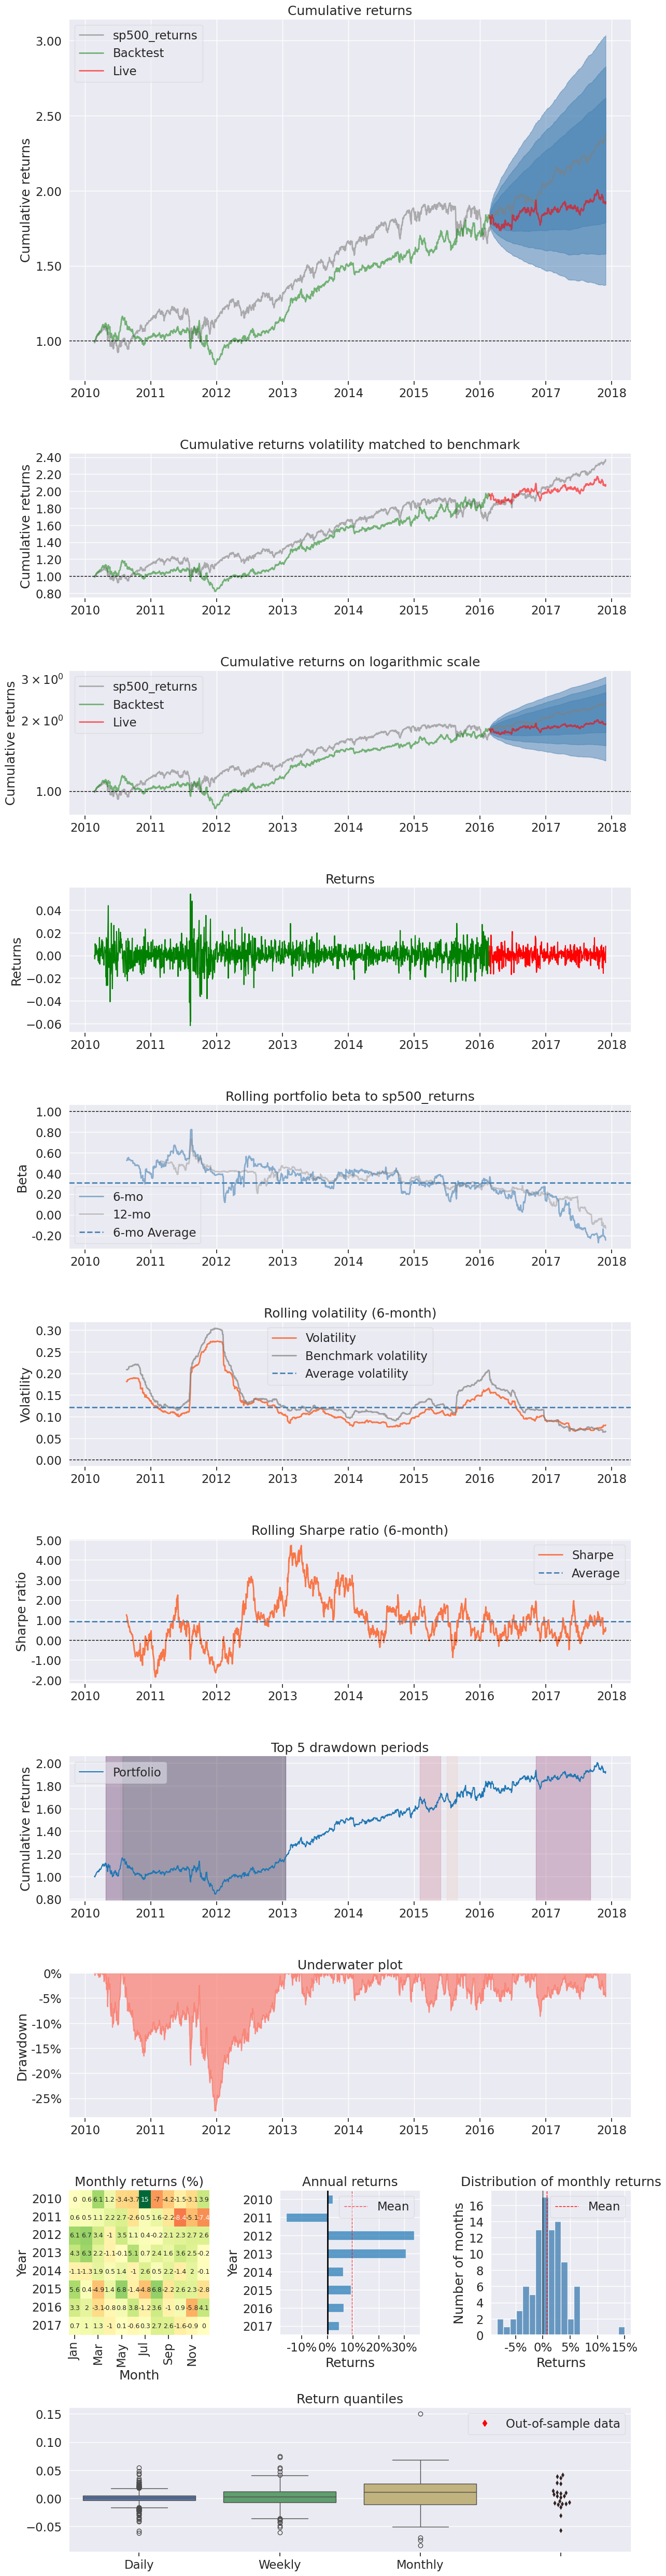

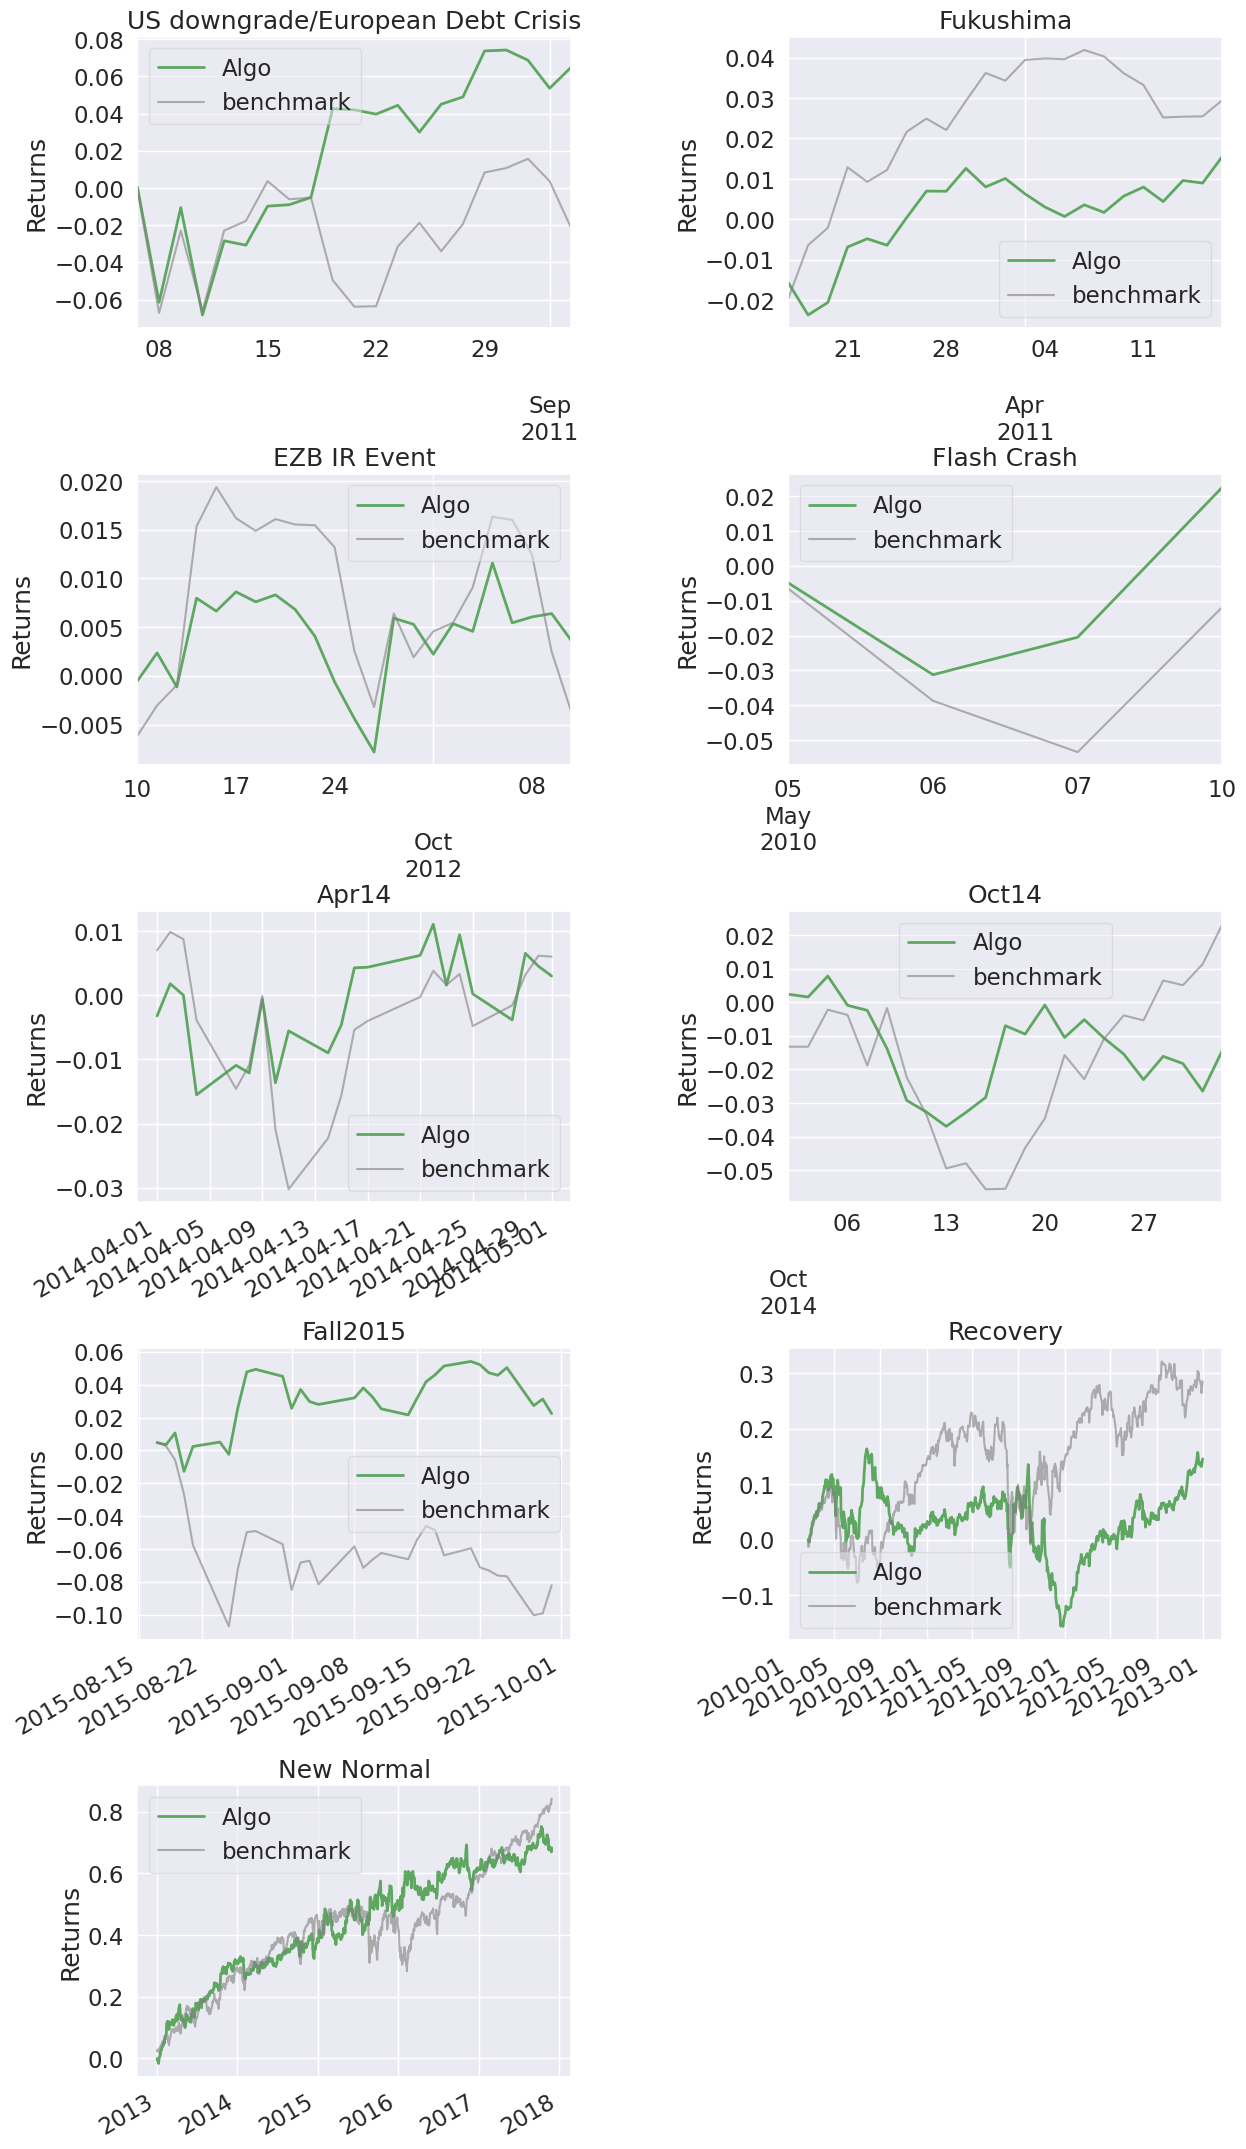

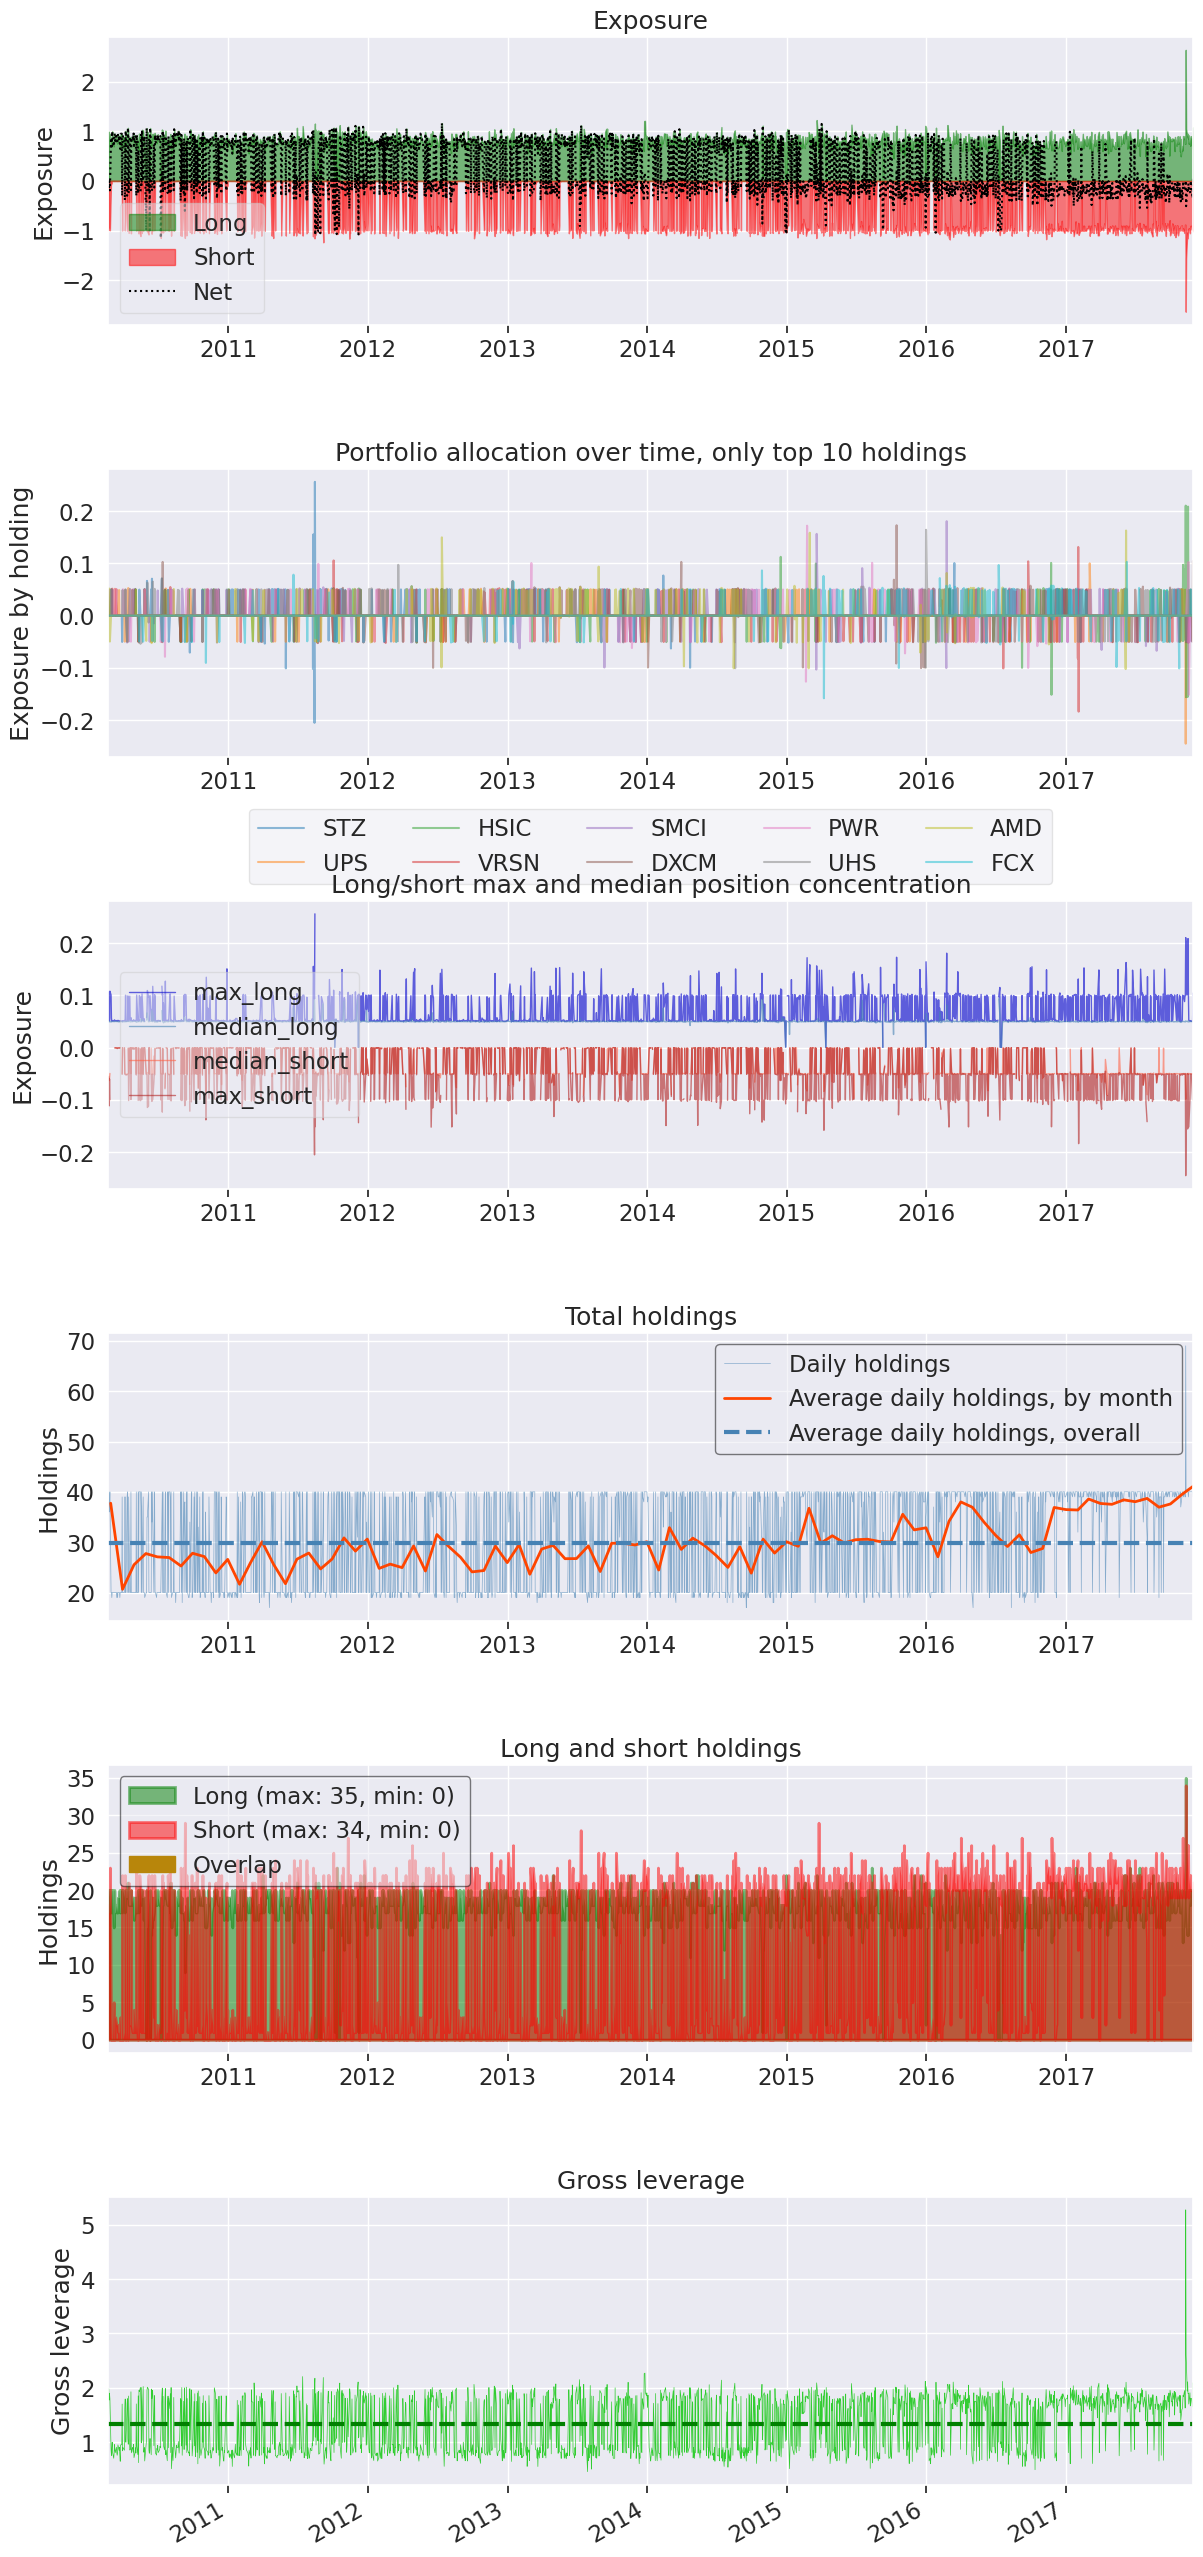

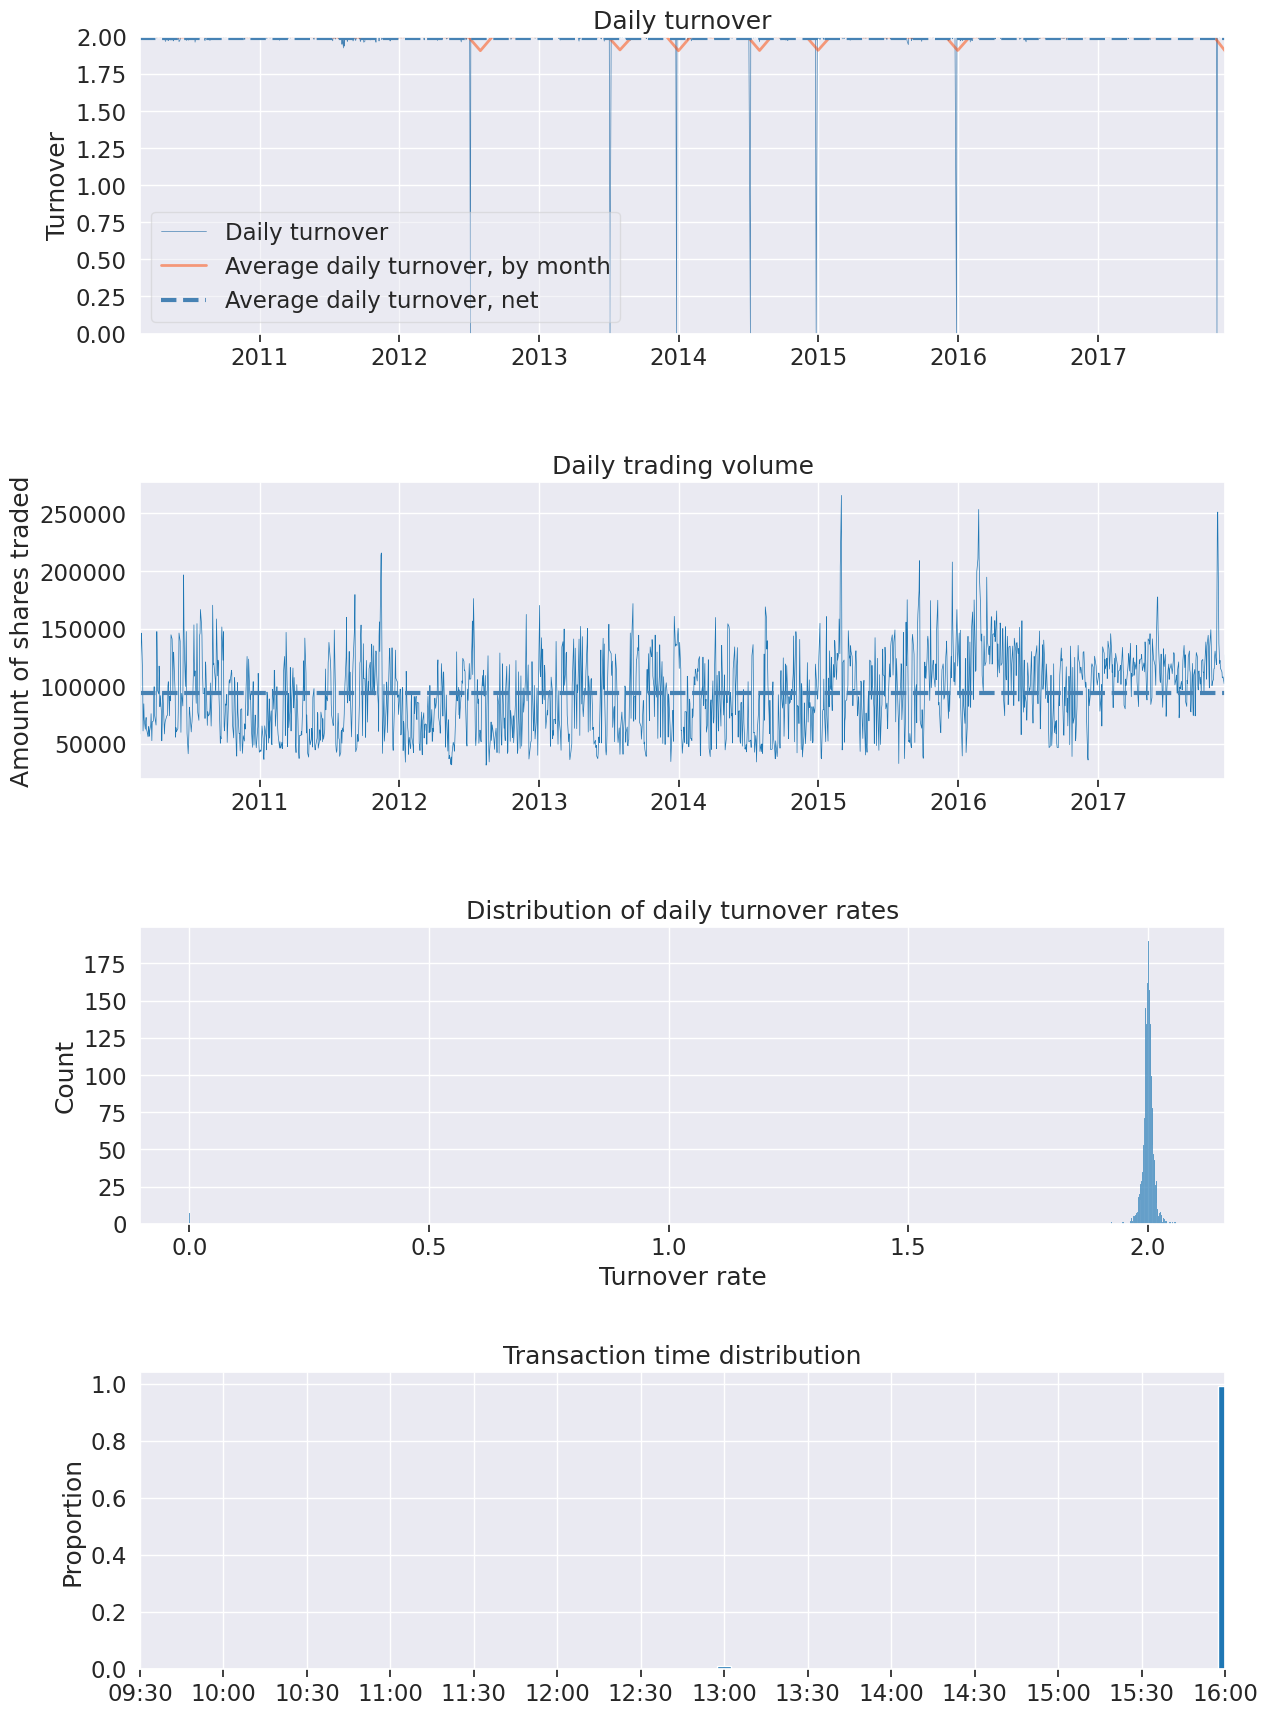

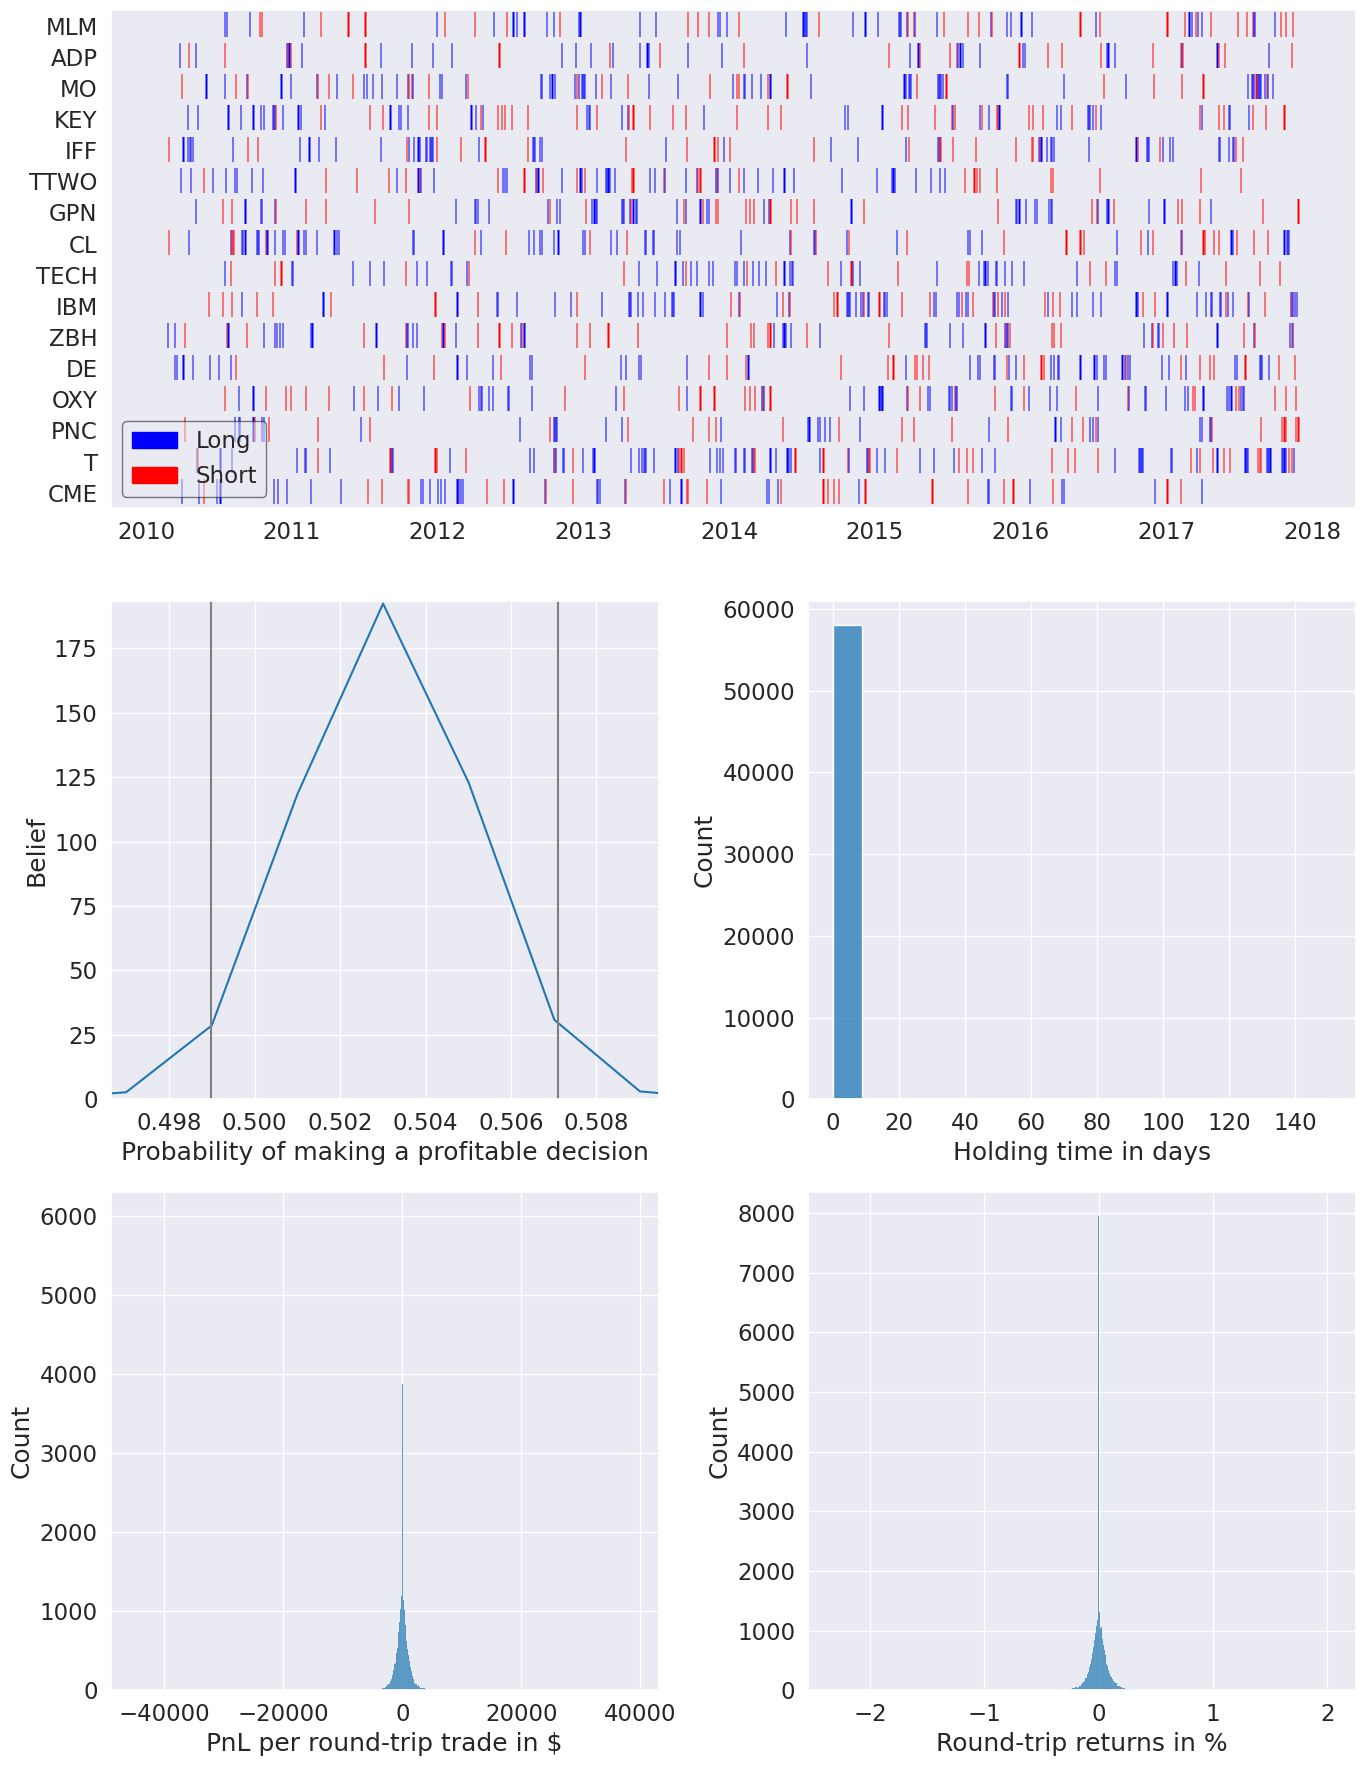

In [22]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)